В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [3]:
y_real = non_smoker_df['charges']
X = non_smoker_df['age']

In [4]:
# Передбачення за допомогою МНК і Numpy
def normal_equations(X,y): # пошук ідеального коефіцієнта (вагів)
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [5]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)),X]
# оскільки формула передбачення Y=θ0+θ1X1, потрібно зробити з вектора матрицю, щоб множити обидва Тета на значення (врахувати його)

In [6]:
MNK_coef = normal_equations(X_with_intercept, y_real) # знаходимо коефіцієнти Тета для формули лінійної регресії
print("Коефіцієнти для МНК:", MNK_coef)

Коефіцієнти для МНК: [-2091.42055657   267.24891283]


In [7]:
predictions_MNK = np.dot(X_with_intercept, MNK_coef) # знаходимо передбачені значення У по формулі регресії

Параметри градієнтного спуску при learning rate = 0.1 та кількість епох = 10: кут нахилу - 4191.634751361632 та зсув (bies) - 4191.634751361633 
Параметри градієнтного спуску при learning rate = 0.01 та кількість епох = 10: кут нахилу - 1413.4457363664567 та зсув (bies) - 1413.4457363664565 
Параметри градієнтного спуску при learning rate = 0.001 та кількість епох = 10: кут нахилу - 165.68119133163162 та зсув (bies) - 165.68119133163162 


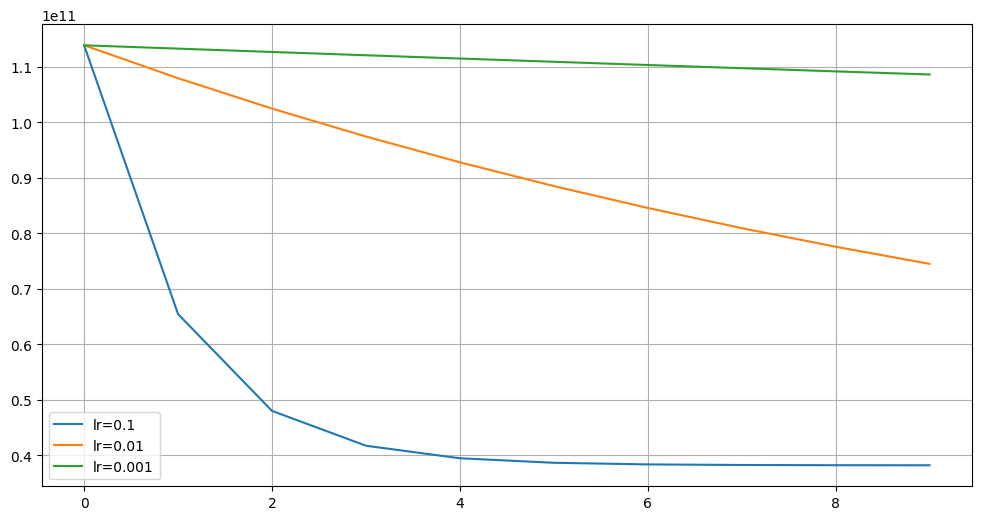

In [53]:
# Передбачення за допомогою градієнтного спуску та Numpy

def full_batch_gradient_descent(X, y, lr, epochs):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

X_with_intercept = np.c_[np.ones((X.shape[0], 1)),X]

epochs = 10

m, b, errors_01 = full_batch_gradient_descent(X_with_intercept, y_real, lr=0.1, epochs=epochs)
predictions_fbgd_01 = m * X + b
print(f"Параметри градієнтного спуску при learning rate = 0.1 та кількість епох = {epochs}: кут нахилу - {m} та зсув (bies) - {b} ")

m, b, errors_001 = full_batch_gradient_descent(X_with_intercept, y_real, lr=0.01, epochs=epochs)
predictions_fbgd_001 = m * X + b
print(f"Параметри градієнтного спуску при learning rate = 0.01 та кількість епох = {epochs}: кут нахилу - {m} та зсув (bies) - {b} ")

m, b, errors_0001 = full_batch_gradient_descent(X_with_intercept, y_real, lr=0.001, epochs=epochs)
predictions_fbgd_0001 = m * X + b
print(f"Параметри градієнтного спуску при learning rate = 0.001 та кількість епох = {epochs}: кут нахилу - {m} та зсув (bies) - {b} ")

plt.figure(figsize=(12, 6))
plt.plot(errors_01, label='lr=0.1')
plt.plot(errors_001, label='lr=0.01')
plt.plot(errors_0001, label='lr=0.001')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Передбачення за допогою Scikitlearn
from sklearn.linear_model import LinearRegression

X_df = X.to_frame() # формування матриці з вектора
lin_reg = LinearRegression()
lin_reg.fit(X_df, y_real)
predictions_sklearn = lin_reg.predict(X_df)
print("Коефіцієнти для scikit-learn.LinearRegression:", [lin_reg.intercept_, lin_reg.coef_])

Коефіцієнти для scikit-learn.LinearRegression: [np.float64(-2091.4205565650864), array([267.24891283])]


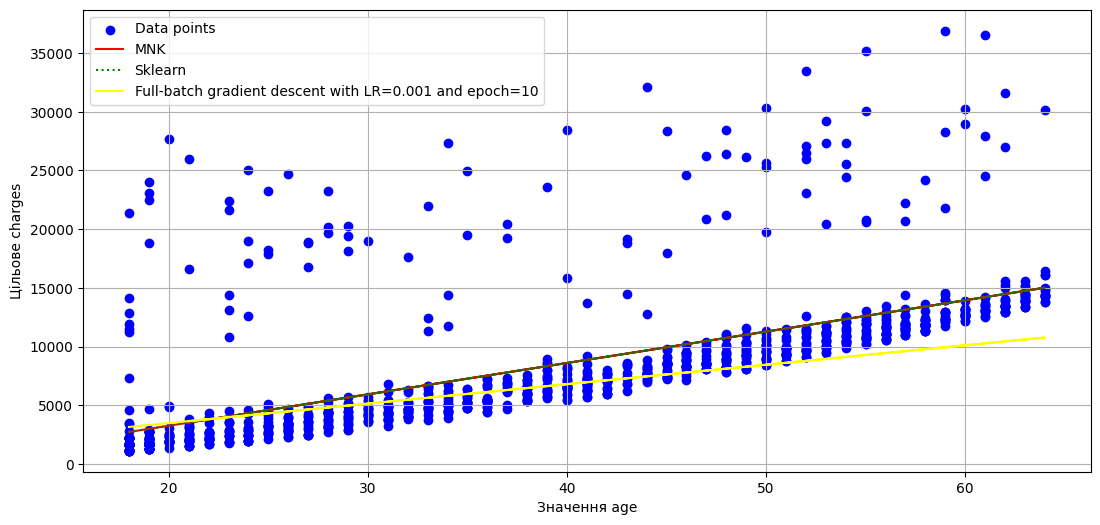

In [57]:
plt.figure(figsize=(13, 6))
plt.scatter(X, y_real, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_sklearn, color='green', label='Sklearn', linestyle='dotted')
#plt.plot(X, predictions_fbgd_01, color='purple', label=f'Full-batch gradient descent with LR=0.1 and epoch={epochs}')
#plt.plot(X, predictions_fbgd_001, color='orange', label=f'Full-batch gradient descent with LR=0.01 and epoch={epochs}')
plt.plot(X, predictions_fbgd_0001, color='yellow', label=f'Full-batch gradient descent with LR=0.001 and epoch={epochs}')
plt.xlabel('Значення age')
plt.ylabel('Цільове charges')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# Оцінимо модель лінійної регресії
mse_np = mean_squared_error(y_real, predictions_MNK)
rmse_np = np.sqrt(mse_np)
mse_sk = mean_squared_error(y_real, predictions_sklearn)
rmse_sk = np.sqrt(mse_sk)
mse_fbgd_01 = mean_squared_error(y_real, predictions_fbgd_01)
rmse_fbgd_01 = np.sqrt(mse_fbgd_01)
mse_fbgd_001 = mean_squared_error(y_real, predictions_fbgd_001)
rmse_fbgd_001 = np.sqrt(mse_fbgd_001)
mse_fbgd_0001 = mean_squared_error(y_real, predictions_fbgd_0001)
rmse_fbgd_0001 = np.sqrt(mse_fbgd_0001)

print('RMSE МНК: ', rmse_np)
print('RMSE sklearn: ', rmse_sk)
print(f'RMSE full-batch gradient descent with LR=0.1 and epochs={epochs}: ', rmse_fbgd_01)
print(f'RMSE full-batch gradient descent with LR=0.01 and epochs={epochs}: ', rmse_fbgd_001)
print(f'RMSE full-batch gradient descent with LR=0.001 and epochs={epochs}: ', rmse_fbgd_0001)

RMSE МНК:  4662.505766636395
RMSE sklearn:  4662.505766636395
RMSE full-batch gradient descent with LR=0.1 and epochs=10:  170132.4177365948
RMSE full-batch gradient descent with LR=0.01 and epochs=10:  51465.70468370388
RMSE full-batch gradient descent with LR=0.001 and epochs=10:  5178.977233867772


Оскільки Sklearn використовує матод найменших квадратів, то результат пісмля застосування LinearRegression та просто з Numpy не відрізняється. Також він є найбільш точний на основі метрики RMSE серед застосованих методів. Алгоритм Full-batch градієнтний спуск показав непоганий результат при рейті навчання 0.001 та 10 епохах, однак не виявився найточнішим.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [64]:
smoker_df = medical_df[medical_df.smoker == 'yes']
y = smoker_df['charges']
X = smoker_df['age']

In [66]:
X_df = X.to_frame() # формування матриці з вектора

lin_reg = LinearRegression()
lin_reg.fit(X_df, y)
predictions = lin_reg.predict(X_df)
print("Коефіцієнти:", [lin_reg.intercept_, lin_reg.coef_])

Коефіцієнти: [np.float64(20294.128126915966), array([305.23760211])]


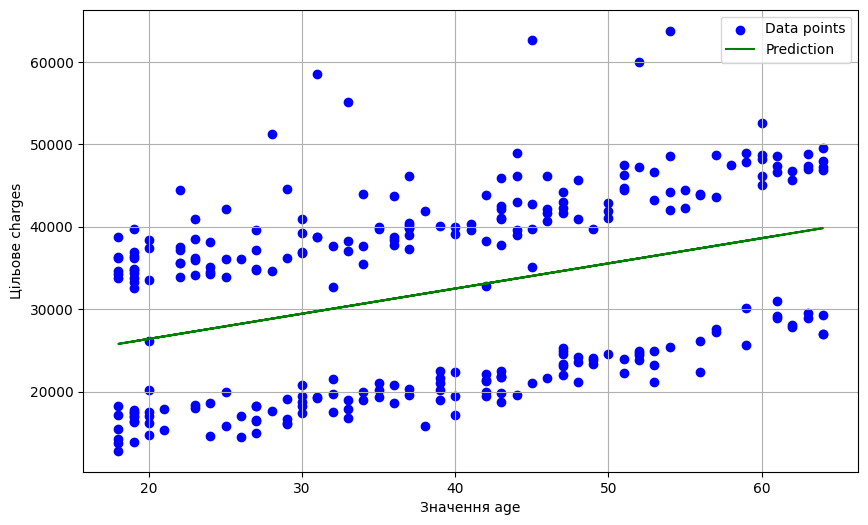

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions, color='green', label='Prediction')
plt.xlabel('Значення age')
plt.ylabel('Цільове charges')
plt.legend()
plt.grid(True)
plt.show()

In [70]:
from sklearn.metrics import mean_absolute_error, r2_score

In [71]:
mse = mean_squared_error(y,predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y,predictions)
r2 = r2_score(y,predictions)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


Побудована модель є поганою, оскільки показник R² сильно менший за 1, а оцінки RMSE та MAE є занадто великими (тобто помилка в приблизно 10тис для медичних зборів - забагато). В компанії я б цю модель не використала.